# ResNet-50 Feature Extraction

This notebook establishes E1 for the Oxford-IIIT Pet transfer learning study.

The main question is:

> **How well can the pretrained ImageNet representation perform when the ResNet-50 backbone is kept fixed and only a new classification head is trained?**

The experiment is:

$$
\boxed{\text{E1 — Feature Extraction}}
$$

The experimental progression is:

```mermaid
flowchart LR
    A["ImageNet Pretrained ResNet-50"] --> B["Freeze Backbone"]
    B --> C["Replace 1000-Class FC with 37-Class FC"]
    C --> D["Train Head Only"]
    D --> E["Validation"]
    E --> F["Test"]
```

Feature Extraction is a form of Transfer Learning in which the pretrained representation is treated as fixed and only the task-specific head is learned.


## Dataset and Experiment Configuration

The experiment uses the Oxford-IIIT Pet dataset for a 37-class breed classification task.

The dataset protocol is:

- Official `trainval` / `test` split
- Stratified 80/20 train-validation split
- Fixed random seed of 42
- Input resolution of $224\times224$
- ImageNet normalization
- Consistent training and evaluation transforms

The official test set is reserved for final evaluation.


In [1]:
import copy
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torchvision.models import (
    ResNet50_Weights,
    resnet50
)

SEED = 42

DATA_ROOT = Path("../data/raw")

IMAGE_SIZE = 224

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Seed:", SEED)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Seed: 42
Device: cuda
GPU: NVIDIA GeForce GTX 1650


## Dataset Setup

The official `trainval` and `test` partitions are loaded using Torchvision.

The `trainval` partition is divided into training and validation subsets using a stratified split with `random_state=42`.

The same split protocol is used throughout the experiment series so that performance differences can be attributed to the model adaptation strategy rather than different data partitions.


In [2]:
dataset_trainval = OxfordIIITPet(
    root=DATA_ROOT,
    split="trainval",
    target_types="category",
    download=False,
)

dataset_test = OxfordIIITPet(
    root=DATA_ROOT,
    split="test",
    target_types="category",
    download=False,
)

indices = np.arange(len(dataset_trainval))
labels = np.array(dataset_trainval._labels)

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    stratify=labels,
    random_state=SEED,
)

print("Train samples:", len(train_indices))
print("Validation samples:", len(val_indices))
print("Test samples:", len(dataset_test))
print("Number of classes:", len(dataset_trainval.classes))

Train samples: 2944
Validation samples: 736
Test samples: 3669
Number of classes: 37


## Image Preprocessing

The preprocessing pipeline remains unchanged from the baseline experiment.

Training uses stochastic augmentation:

```mermaid
flowchart LR
    A["Original Image"] --> B["RandomResizedCrop"]
    B --> C["RandomHorizontalFlip"]
    C --> D["ToTensor"]
    D --> E["ImageNet Normalization"]
    E --> F["224 × 224 Tensor"]
```

Validation and test use deterministic preprocessing:

```text
Resize → CenterCrop → ToTensor → Normalize
```

Keeping the preprocessing fixed allows us to attribute performance differences primarily to the change in model initialization.

In [3]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

## Dataset and DataLoader

The train, validation, and test datasets use the same subset structure as the baseline experiment.

The main difference in E1 is not the data pipeline.

It is the model initialization.

```mermaid
flowchart LR
    A["Train Dataset"] --> B["Train DataLoader"]
    C["Validation Dataset"] --> D["Validation DataLoader"]
    E["Test Dataset"] --> F["Test DataLoader"]
```

In [4]:
class OxfordPetSubset(Dataset):
    def __init__(
        self,
        base_dataset,
        indices,
        transform=None,
    ):
        self.base_dataset = base_dataset
        self.indices = np.asarray(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        real_index = self.indices[index]

        image, label = self.base_dataset[real_index]

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [5]:
train_dataset = OxfordPetSubset(
    base_dataset=dataset_trainval,
    indices=train_indices,
    transform=train_transform,
)

val_dataset = OxfordPetSubset(
    base_dataset=dataset_trainval,
    indices=val_indices,
    transform=eval_transform,
)

test_dataset = OxfordPetSubset(
    base_dataset=dataset_test,
    indices=np.arange(len(dataset_test)),
    transform=eval_transform,
)

In [6]:
BATCH_SIZE = 16
NUM_WORKERS = 2
PIN_MEMORY = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Label range:", labels.min().item(), labels.max().item())

Images shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])
Label range: 1 35


## Build the ImageNet-Pretrained ResNet-50

We start from the ImageNet-pretrained ResNet-50 provided by Torchvision.

The key initialization is:

$$
\theta_0=\theta_{\text{ImageNet}}
$$

At this stage, the backbone is used as a fixed feature extractor.


In [7]:
weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)

print("Loaded pretrained ResNet-50.")
print("Weights:", weights)


Loaded pretrained ResNet-50.
Weights: ResNet50_Weights.IMAGENET1K_V2


## Replace the Classification Head and Freeze the Backbone

The pretrained ResNet-50 was originally trained for ImageNet-1K:

$$
\hat{y} \in \mathbb{R}^{1000}
$$

Our target task has 37 breeds:

$$
\hat{y} \in \mathbb{R}^{37}
$$

We first freeze all pretrained backbone parameters and then replace the original classifier with a new 37-class head.

The resulting trainability pattern is:

```mermaid
flowchart LR
    A["Pretrained Backbone"] --> B["Frozen Features"]
    B --> C["New 37-Class FC"]
    C --> D["Trainable Prediction"]
```

Only the new classification head is updated during optimization.


In [8]:
for parameter in model.parameters():
    parameter.requires_grad = False

num_classes = 37
in_features = model.fc.in_features

model.fc = nn.Linear(
    in_features,
    num_classes,
)

print(model.fc)


Linear(in_features=2048, out_features=37, bias=True)


## Verify Trainable Parameters

In Feature Extraction, the pretrained backbone is frozen and only the new classification head is trainable.

Therefore:

$$
\theta_{\text{backbone}}^{\text{new}}
=
\theta_{\text{backbone}}^{\text{old}}
$$

while the classifier parameters are updated:

$$
\theta_{\text{head}}^{\text{new}}
\neq
\theta_{\text{head}}^{\text{old}}
$$

The trainable parameter count should therefore be much smaller than the total parameter count.


In [9]:
model = model.to(device)

total_params = sum(parameter.numel() for parameter in model.parameters())

trainable_params = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(
    f"Trainable ratio:      "
    f"{trainable_params / total_params:.2%}"
)

Total parameters:     23,583,845
Trainable parameters: 75,813
Trainable ratio:      0.32%


## Training Objective

The target remains the same 37-class classification problem.

For an input image $x$, the model produces:

$$
z=f_\theta(x)
$$

where:

$$
z\in\mathbb{R}^{37}
$$

The Cross-Entropy loss is:

$$
\mathcal{L}
=
-\log p_y
$$

The optimization objective is:

$$
\theta^*
=
\arg\min_\theta
\frac{1}{N}
\sum_{i=1}^{N}
\mathcal{L}
\left(
f_\theta(x_i),y_i
\right)
$$

The crucial difference from E0 is the starting point:

$$
\theta_0=\theta_{\text{ImageNet}}
$$

rather than a random initialization.

## Optimizer and Training Configuration

Only the new classification head is trainable, so the optimizer receives only parameters with `requires_grad=True`.

The baseline configuration is:

- AdamW
- learning rate $10^{-3}$
- weight decay $10^{-4}$
- cosine learning-rate schedule
- 30 training epochs

The purpose of E1 is to measure the transferability of the frozen ImageNet representation before allowing any backbone adaptation.


In [10]:
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 30

criterion = nn.CrossEntropyLoss()

optimizer = AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        model.parameters(),
    ),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
)


## Training Loop

The training procedure follows the same optimization cycle as E0.

```mermaid
flowchart LR
    A["Mini-Batch"] --> B["Forward"]
    B --> C["Loss"]
    C --> D["Backward"]
    D --> E["Parameter Update"]
    E --> F["Next Batch"]
```

The difference is that the gradients now update parameters that already contain ImageNet-learned representations.

Therefore, each update performs:

$$
\theta_{t+1}
=
\theta_t
-
\eta
\nabla_\theta\mathcal{L}_t
$$

starting from:

$$
\theta_0=\theta_{\text{ImageNet}}
$$

In [11]:
def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    device=device
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(logits, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        prediction = logits.argmax(dim=1)

        correct += (prediction == labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [12]:
def evaluate(
    model,
    dataloader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.inference_mode():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)

            loss = criterion(logits, labels)

            running_loss += loss.item() * images.size(0)

            prediction = logits.argmax(dim=1)

            correct += (prediction == labels).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy   

## Training History

We record the same quantities as the scratch experiment:

- training loss
- training accuracy
- validation loss
- validation accuracy
- learning rate

This allows direct comparison between E0 and E1.

In [13]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": [],
}

## Best Checkpoint

The checkpoint with the highest validation accuracy is selected as the E1 model.

The selection process is:

```mermaid
flowchart LR
    A["Epoch"] --> B["Validation Accuracy"]
    B --> C{"Better Than Best?"}
    C -->|Yes| D["Save Checkpoint"]
    C -->|No| E["Keep Previous Best"]
```

The official test set is not used during this selection process.

In [14]:
checkpoint_dir = Path("../experiments/checkpoints")

checkpoint_dir.mkdir(
    parents=True,
    exist_ok=True,
)

best_val_accuracy = 0.0

for epoch in range(NUM_EPOCHS):
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device=device,
    )

    val_loss, val_accuracy = evaluate(
        model,
        val_loader,
        criterion,
        device=device,
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    history["learning_rate"].append(current_lr)

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_accuracy": val_accuracy,
            },
            checkpoint_dir / "resnet50_feature_extraction_best.pt",
        )

    scheduler.step()

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2%} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2%} | "
        f"LR: {current_lr:.2e}"
    )


Epoch [01/30] | Train Loss: 2.1493 | Train Acc: 54.89% | Val Loss: 0.9769 | Val Acc: 88.59% | LR: 1.00e-03
Epoch [02/30] | Train Loss: 1.0137 | Train Acc: 78.94% | Val Loss: 0.5367 | Val Acc: 90.35% | LR: 9.97e-04
Epoch [03/30] | Train Loss: 0.7789 | Train Acc: 81.52% | Val Loss: 0.4009 | Val Acc: 92.39% | LR: 9.89e-04
Epoch [04/30] | Train Loss: 0.7160 | Train Acc: 81.49% | Val Loss: 0.3442 | Val Acc: 91.30% | LR: 9.76e-04
Epoch [05/30] | Train Loss: 0.6157 | Train Acc: 83.73% | Val Loss: 0.3266 | Val Acc: 90.90% | LR: 9.57e-04
Epoch [06/30] | Train Loss: 0.5868 | Train Acc: 84.21% | Val Loss: 0.2904 | Val Acc: 92.66% | LR: 9.33e-04
Epoch [07/30] | Train Loss: 0.5307 | Train Acc: 85.53% | Val Loss: 0.2743 | Val Acc: 92.66% | LR: 9.05e-04
Epoch [08/30] | Train Loss: 0.4897 | Train Acc: 86.58% | Val Loss: 0.2701 | Val Acc: 92.39% | LR: 8.72e-04
Epoch [09/30] | Train Loss: 0.4800 | Train Acc: 86.92% | Val Loss: 0.2531 | Val Acc: 93.07% | LR: 8.35e-04
Epoch [10/30] | Train Loss: 0.4841 | 

## Load the Best Validation Checkpoint

After training, we restore the checkpoint that achieved the highest validation accuracy.

This becomes the final E1 model used for test evaluation.

In [15]:
checkpoint = torch.load(
    checkpoint_dir / "resnet50_feature_extraction_best.pt",
    map_location=device,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

best_epoch = checkpoint["epoch"]

print("Best epoch:", best_epoch)
print(
    "Best validation accuracy:",
    f"{checkpoint['val_accuracy']:.2%}",
)


Best epoch: 16
Best validation accuracy: 93.75%


## Learning Curves

We compare the training and validation behavior of the pretrained model.

The curves help us determine:

- how quickly ImageNet initialization enables learning
- whether validation performance improves rapidly
- whether the model begins to overfit
- how the training dynamics differ from E0

The most important comparison with E0 is not only the final accuracy, but also the optimization trajectory.

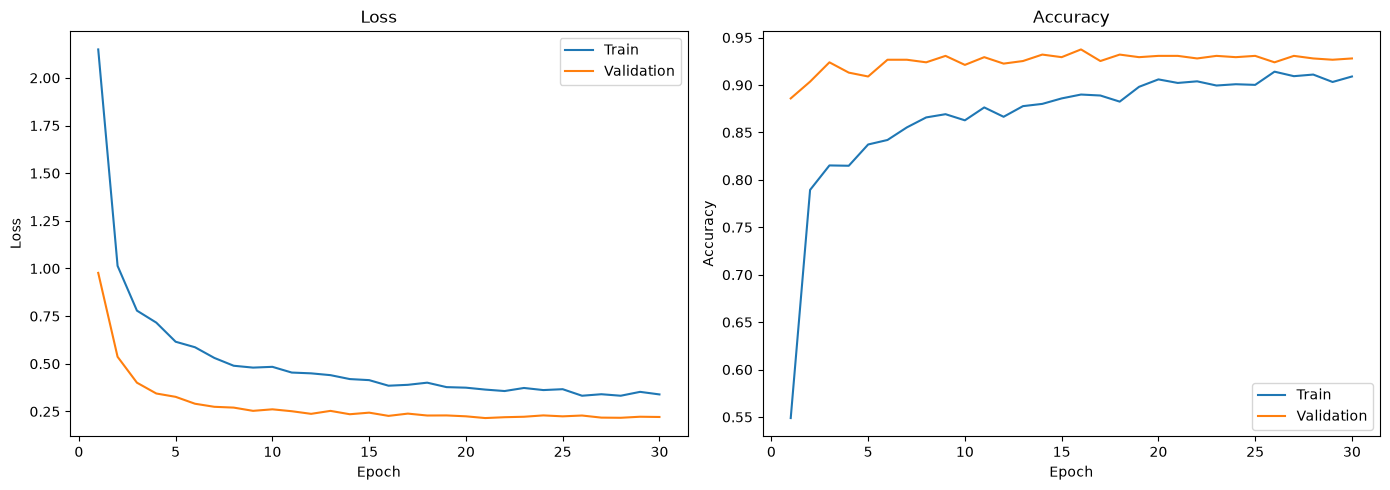

In [16]:
epochs = range(
    1,
    NUM_EPOCHS + 1,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

axes[0].plot(
    epochs,
    history["train_loss"],
    label="Train",
)

axes[0].plot(
    epochs,
    history["val_loss"],
    label="Validation",
)

axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(
    epochs,
    history["train_accuracy"],
    label="Train",
)

axes[1].plot(
    epochs,
    history["val_accuracy"],
    label="Validation",
)

axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

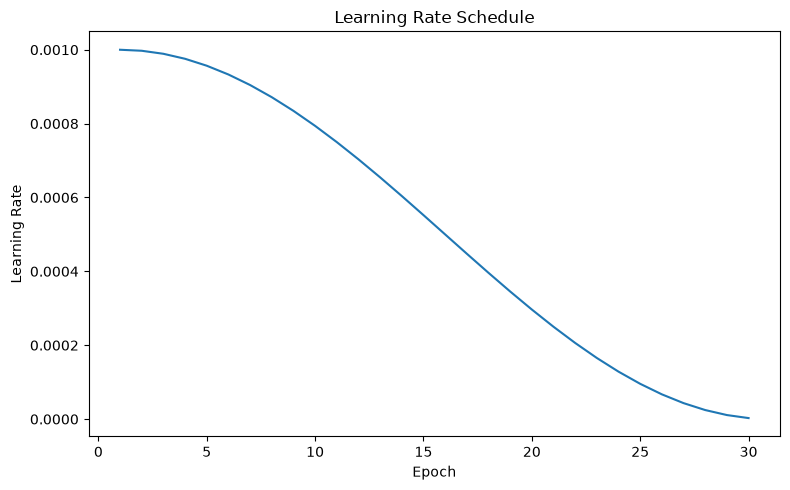

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["learning_rate"],
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")

plt.tight_layout()
plt.show()

## Validation Evaluation

The validation set determines the best E1 checkpoint.

We report:

- validation loss
- validation accuracy

The validation result is used for model selection, not as the final generalization estimate.

In [19]:
best_val_loss, best_val_accuracy = evaluate(
    model=model,
    dataloader=val_loader,
    criterion=criterion,
    device=device,
)

print(
    f"Best Validation Loss: "
    f"{best_val_loss:.4f}"
)

print(
    f"Best Validation Accuracy: "
    f"{best_val_accuracy:.2%}"
)

print("Best Epoch:", best_epoch)

Best Validation Loss: 0.2267
Best Validation Accuracy: 93.75%
Best Epoch: 16


## Final Evaluation on the Test Set

After selecting the best E1 checkpoint using the validation set, we evaluate it on the official test set.

The evaluation protocol is:

```mermaid
flowchart LR
    A["Train"] --> B["Validation"]
    B --> C["Select Best E1 Checkpoint"]
    C --> D["Official Test Set"]
    D --> E["Final E1 Result"]
```

The test set is not used to tune the model or choose the checkpoint.

In [21]:
test_loss, test_accuracy = evaluate(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device,
)

print(f"E1 Test Loss: {test_loss:.4f}")
print(f"E1 Test Accuracy: {test_accuracy:.2%}")

E1 Test Loss: 0.2922
E1 Test Accuracy: 91.14%


## E1 Result Interpretation

E1 measures how useful the ImageNet representation is when it is treated as a fixed feature extractor.

The backbone does not adapt to Oxford-IIIT Pet:

$$
\theta_{\text{backbone}}^{\text{new}}
=
\theta_{\text{backbone}}^{\text{old}}
$$

Only the new classifier is optimized.

The result answers:

> **Are the pretrained ImageNet features already sufficiently discriminative for the 37-class pet-breed task?**

If performance improves further after unfreezing higher-level layers in E2, that will provide evidence that the pretrained representation is useful but still benefits from task-specific adaptation.


In [22]:
e1_result = pd.DataFrame([{
    "experiment": "E1",
    "model": "ResNet-50",
    "initialization": "ImageNet",
    "strategy": "Feature Extraction",
    "trainable_params": trainable_params,
    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "best_epoch": best_epoch,
    "best_val_accuracy": best_val_accuracy,
    "best_val_loss": best_val_loss,
    "test_accuracy": test_accuracy,
    "test_loss": test_loss,
}])

e1_result


,experiment,model,initialization,strategy,trainable_params,epochs,batch_size,learning_rate,weight_decay,best_epoch,best_val_accuracy,best_val_loss,test_accuracy,test_loss
0,E1,ResNet-50,ImageNet,Feature Extraction,75813,30,16,0.001,0.0001,16,0.9375,0.226684,0.91142,0.292235


In [23]:
results_dir = Path("../experiments/results")
results_dir.mkdir(parents=True, exist_ok=True)

e1_result.to_csv(
    results_dir / "e1_feature_extraction.csv",
    index=False,
)

results_path = results_dir / "experiment_results.csv"

if results_path.exists():
    experiment_results = pd.read_csv(results_path)
    experiment_results = experiment_results[
        experiment_results["experiment"] != "E1"
    ]
    experiment_results = pd.concat(
        [experiment_results, e1_result],
        ignore_index=True,
    )
else:
    experiment_results = e1_result.copy()

experiment_results.to_csv(
    results_path,
    index=False,
)

print("Saved:", results_dir / "e1_feature_extraction.csv")
print("Updated:", results_path)


Saved: ../experiments/results/e1_feature_extraction.csv
Updated: ../experiments/results/experiment_results.csv


# Conclusions

E1 establishes the Feature Extraction baseline.

The ImageNet-pretrained ResNet-50 backbone is kept frozen, while only the new 37-class classification head is trained.

The next experiment relaxes this constraint by allowing the highest-level ResNet stage to adapt:

> **E2 — Pretrained ResNet-50 + Layer4 Fine-Tuning**
